# Pretrained WideResNet50-2 Backbone Notebook

This notebook evaluates a frozen ImageNet-pretrained `WideResNet50-2` backbone on the shared `64x64` 5% test-defect split without using an autoencoder or PatchCore.


In [2]:
from pathlib import Path
import json
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader

try:
    import umap.umap_ as umap
except ImportError as exc:
    raise ImportError(
        "UMAP is required for this notebook. Install it with: pip install umap-learn"
    ) from exc

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
REPO_ROOT = None
for candidate in candidate_roots:
    if (candidate / "src" / "wafer_defect").exists() and (candidate / "configs").exists():
        REPO_ROOT = candidate
        break

if REPO_ROOT is None:
    raise RuntimeError("Could not locate repo root containing src/wafer_defect and configs/")

SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from wafer_defect.config import load_toml
from wafer_defect.data.wm811k import WaferMapDataset
from wafer_defect.evaluation import export_reference_umap_bundle, summarize_threshold_metrics, sweep_threshold_metrics

from torchvision.models import Wide_ResNet50_2_Weights, wide_resnet50_2


In [3]:
CONFIG_PATH = REPO_ROOT / "configs" / "training" / "train_wideresnet50_backbone.toml"
config = load_toml(CONFIG_PATH)
PCA_MAX_POINTS_PER_GROUP = 500
UMAP_MAX_POINTS_PER_GROUP = 5000
UMAP_MAX_TRAIN_REFERENCE = 5000

# Optional quick smoke-run overrides:
# config["data"]["metadata_csv"] = "data/processed/x64/wm811k/metadata_dev.csv"
# config["run"]["output_dir"] = "artifacts/x64/wideresnet50_embedding_dev"

config


{'run': {'output_dir': 'artifacts/x64/wideresnet50A_embedding_baseline',
  'seed': 42},
 'data': {'metadata_csv': 'data/processed/x64/wm811k/metadata_50k_5pct_holdout70k_3p5k.csv',
  'image_size': 224,
  'batch_size': 64,
  'num_workers': 4},
 'training': {'device': 'auto'},
 'model': {'type': 'wideresnet50_backbone',
  'pretrained': True,
  'freeze_backbone': True,
  'input_size': 224,
  'normalize_imagenet': True},
 'scoring': {'name': 'center_l2', 'threshold_quantile': 0.95}}

In [4]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def resolve_device(device_name: str) -> torch.device:
    if device_name == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return torch.device(device_name)


set_seed(int(config["run"]["seed"]))

device = resolve_device(config["training"].get("device", "auto"))
print("Resolved device:", device)
print("CUDA available:", torch.cuda.is_available())
device



Resolved device: cuda
CUDA available: True


device(type='cuda')

In [6]:
image_size = int(config["data"].get("image_size", 64))
batch_size = int(config["data"].get("batch_size", 64))
num_workers = int(config["data"].get("num_workers", 0))
metadata_path = REPO_ROOT / config["data"]["metadata_csv"]
metadata = pd.read_csv(metadata_path)

display(metadata.head())
display(metadata["split"].value_counts().rename_axis("split").to_frame("count"))
display(metadata["is_anomaly"].value_counts().rename_axis("is_anomaly").to_frame("count"))

train_dataset = WaferMapDataset(metadata_path, split="train", image_size=image_size)
val_dataset = WaferMapDataset(metadata_path, split="val", image_size=image_size)
test_dataset = WaferMapDataset(metadata_path, split="test", image_size=image_size)

pin_memory = device.type == "cuda"
persistent_workers = num_workers > 0

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
)

print(f"train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}")


,array_path,label,defect_type,is_anomaly,split,source_split,original_height,original_width
0,data/processed/x64/wm811k/arrays/wafer_0000000...,none,none,0,train,Training,25,27
1,data/processed/x64/wm811k/arrays/wafer_0000001...,none,none,0,train,Training,55,66
2,data/processed/x64/wm811k/arrays/wafer_0000002...,none,none,0,train,Test,33,29
3,data/processed/x64/wm811k/arrays/wafer_0000003...,none,none,0,train,Training,25,26
4,data/processed/x64/wm811k/arrays/wafer_0000004...,none,none,0,train,Test,39,37


,count
split,
test,73500
train,40000
val,5000


,count
is_anomaly,
0,115000
1,3500


train=40000, val=5000, test=73500


In [7]:
class WideResNet50_2FeatureExtractor(torch.nn.Module):
    """Pretrained WideResNet50-2 adapted for single-channel wafer maps."""

    def __init__(
        self,
        pretrained: bool = True,
        input_size: int = 224,
        freeze_backbone: bool = True,
        normalize_imagenet: bool = True,
    ) -> None:
        super().__init__()
        weights = Wide_ResNet50_2_Weights.DEFAULT if pretrained else None
        backbone = wide_resnet50_2(weights=weights)

        original_conv = backbone.conv1
        adapted_conv = torch.nn.Conv2d(
            1,
            original_conv.out_channels,
            kernel_size=original_conv.kernel_size,
            stride=original_conv.stride,
            padding=original_conv.padding,
            bias=False,
        )
        with torch.no_grad():
            adapted_conv.weight.copy_(original_conv.weight.mean(dim=1, keepdim=True))
        backbone.conv1 = adapted_conv

        self.stem = torch.nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
        )
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4
        self.layers = torch.nn.Sequential(
            self.layer1,
            self.layer2,
            self.layer3,
            self.layer4,
        )
        self.avgpool = backbone.avgpool
        self.embedding_dim = backbone.fc.in_features
        self.input_size = int(input_size)
        self.normalize_imagenet = bool(normalize_imagenet)
        self.register_buffer("image_mean", torch.tensor([0.4490], dtype=torch.float32).view(1, 1, 1, 1))
        self.register_buffer("image_std", torch.tensor([0.2260], dtype=torch.float32).view(1, 1, 1, 1))

        if freeze_backbone:
            for parameter in self.parameters():
                parameter.requires_grad = False

    def preprocess(self, x: torch.Tensor) -> torch.Tensor:
        if x.shape[-1] != self.input_size or x.shape[-2] != self.input_size:
            x = torch.nn.functional.interpolate(
                x, size=(self.input_size, self.input_size), mode="bilinear", align_corners=False
            )
        if self.normalize_imagenet:
            x = (x - self.image_mean) / self.image_std
        return x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.preprocess(x)
        x = self.stem(x)
        x = self.layers(x)
        x = self.avgpool(x)
        return torch.flatten(x, 1)


model = WideResNet50_2FeatureExtractor(
    pretrained=bool(config["model"].get("pretrained", True)),
    input_size=int(config["model"].get("input_size", 224)),
    freeze_backbone=bool(config["model"].get("freeze_backbone", True)),
    normalize_imagenet=bool(config["model"].get("normalize_imagenet", True)),
).to(device)


def collect_embeddings(dataloader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    embeddings = []
    labels = []
    model.eval()

    with torch.inference_mode():
        autocast_enabled = device.type == "cuda"
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=autocast_enabled):
            for inputs, batch_labels in dataloader:
                inputs = inputs.to(device, non_blocking=True)
                batch_embeddings = model(inputs)
                embeddings.append(batch_embeddings.detach().cpu())
                labels.append(batch_labels.cpu())

    embeddings = torch.cat(embeddings, dim=0).numpy().astype(np.float32)
    labels = torch.cat(labels, dim=0).numpy()
    return embeddings, labels

def l2_center_scores(embeddings: np.ndarray, center: np.ndarray) -> np.ndarray:
    return np.linalg.norm(embeddings - center[None, :], axis=1).astype(np.float32)

model = model.to(device)
model.eval()

print("Resolved device:", device)
print("Model device:", next(model.parameters()).device)
print("Batch size:", train_loader.batch_size)
print("Num workers:", train_loader.num_workers)

Resolved device: cuda
Model device: cuda:0
Batch size: 64
Num workers: 4


In [8]:
from tqdm.auto import tqdm
import time

print("========== Evaluation Pipeline ==========")

t0 = time.time()

output_dir = REPO_ROOT / config["run"]["output_dir"]
eval_dir = output_dir / "evaluation"
plots_dir = eval_dir / "plots"
output_dir.mkdir(parents=True, exist_ok=True)
eval_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

print("Output directory:", output_dir)

# -----------------------------
# Collect embeddings
# -----------------------------
print("\n[1/4] Collecting embeddings")

print(" -> Train embeddings")
train_embeddings, train_labels = collect_embeddings(tqdm(train_loader))

print(" -> Validation embeddings")
val_embeddings, val_labels = collect_embeddings(tqdm(val_loader))

print(" -> Test embeddings")
test_embeddings, test_labels = collect_embeddings(tqdm(test_loader))

# -----------------------------
# Compute anomaly scores
# -----------------------------
print("\n[2/4] Computing center and anomaly scores")

train_center = train_embeddings.mean(axis=0).astype(np.float32)

val_scores = l2_center_scores(val_embeddings, train_center)
test_scores = l2_center_scores(test_embeddings, train_center)

val_scores_df = pd.DataFrame({
    "score": val_scores,
    "is_anomaly": val_labels.astype(int)
})

test_scores_df = pd.DataFrame({
    "score": test_scores,
    "is_anomaly": test_labels.astype(int)
})

# -----------------------------
# Threshold selection
# -----------------------------
print("\n[3/4] Selecting threshold")

threshold_quantile = float(config["scoring"].get("threshold_quantile", 0.95))

val_normal_scores = val_scores_df.loc[
    val_scores_df["is_anomaly"] == 0,
    "score"
]

threshold = float(val_normal_scores.quantile(threshold_quantile))

metrics = summarize_threshold_metrics(
    test_labels.astype(int),
    test_scores,
    threshold
)

threshold_sweep_df, best_sweep = sweep_threshold_metrics(
    test_labels.astype(int),
    test_scores
)

# -----------------------------
# Save outputs
# -----------------------------
print("\n[4/4] Saving evaluation artifacts")

checkpoint_payload = {
    "model_type": "wideresnet50_backbone",
    "config": config,
    "model_state_dict": model.state_dict(),
}
torch.save(checkpoint_payload, output_dir / "wideresnet50_backbone_baseline.pth")

np.save(output_dir / "train_center.npy", train_center)
np.save(eval_dir / "train_embeddings.npy", train_embeddings)
np.save(eval_dir / "train_labels.npy", train_labels.astype(np.int64))
np.save(eval_dir / "val_embeddings.npy", val_embeddings)
np.save(eval_dir / "val_labels.npy", val_labels.astype(np.int64))
np.save(eval_dir / "test_embeddings.npy", test_embeddings)
np.save(eval_dir / "test_labels.npy", test_labels.astype(np.int64))
np.save(eval_dir / "val_scores.npy", val_scores)
np.save(eval_dir / "test_scores.npy", test_scores)

val_scores_df.to_csv(eval_dir / "val_scores.csv", index=False)
test_scores_df.to_csv(eval_dir / "test_scores.csv", index=False)
threshold_sweep_df.to_csv(eval_dir / "threshold_sweep.csv", index=False)

summary = {
    "backbone": "wideresnet50_2",
    "model_type": "wideresnet50_backbone",
    "checkpoint_path": str(output_dir / "wideresnet50_backbone_baseline.pth"),
    "pretrained": bool(config["model"].get("pretrained", True)),
    "freeze_backbone": bool(config["model"].get("freeze_backbone", True)),
    "input_size": int(config["model"].get("input_size", 224)),
    "embedding_dim": int(train_embeddings.shape[1]),
    "train_center_norm": float(np.linalg.norm(train_center)),
    "threshold_quantile": threshold_quantile,
    "threshold": threshold,
    "metrics_at_validation_threshold": metrics,
    "best_threshold_sweep": best_sweep,
    "saved_arrays": {
        "train_embeddings": str(eval_dir / "train_embeddings.npy"),
        "val_embeddings": str(eval_dir / "val_embeddings.npy"),
        "test_embeddings": str(eval_dir / "test_embeddings.npy"),
        "test_labels": str(eval_dir / "test_labels.npy"),
    },
}

with (eval_dir / "summary.json").open("w", encoding="utf-8") as handle:
    json.dump(summary, handle, indent=2)

elapsed = time.time() - t0

print("\nSaved outputs to:", output_dir)
print(f"Checkpoint saved to: {output_dir / 'wideresnet50_backbone_baseline.pth'}")
print(f"Total runtime: {elapsed:.2f}s")

summary


========== Evaluation Pipeline ==========
Output directory: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x64\wideresnet50A_embedding_baseline

[1/4] Collecting embeddings
 -> Train embeddings


  0%|          | 0/625 [00:07<?, ?it/s]

 -> Validation embeddings


  0%|          | 0/79 [00:08<?, ?it/s]

 -> Test embeddings


  0%|          | 0/1149 [00:08<?, ?it/s]


[2/4] Computing center and anomaly scores

[3/4] Selecting threshold

[4/4] Saving evaluation artifacts

Saved outputs to: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x64\wideresnet50A_embedding_baseline
Checkpoint saved to: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x64\wideresnet50A_embedding_baseline\wideresnet50_backbone_baseline.pth
Total runtime: 211.40s


{'backbone': 'wideresnet50_2',
 'model_type': 'wideresnet50_backbone',
 'checkpoint_path': 'C:\\Users\\User\\Desktop\\Term 8\\Deep Learning\\Project\\DeepLearning-Group8\\artifacts\\x64\\wideresnet50A_embedding_baseline\\wideresnet50_backbone_baseline.pth',
 'pretrained': True,
 'freeze_backbone': True,
 'input_size': 224,
 'embedding_dim': 2048,
 'train_center_norm': 14.33398151397705,
 'threshold_quantile': 0.95,
 'threshold': 8.660283422470092,
 'metrics_at_validation_threshold': {'threshold': 8.660283422470092,
  'precision': 0.2426606446314925,
  'recall': 0.3377142857142857,
  'f1': 0.28240353601720225,
  'auroc': 0.6971896408163266,
  'auprc': 0.17238885522491534,
  'predicted_anomalies': 4871,
  'confusion_matrix': [[66311, 3689], [2318, 1182]]},
 'best_threshold_sweep': {'threshold': 9.735737800598145,
  'precision': 0.3973727422003284,
  'recall': 0.2765714285714286,
  'f1': 0.326145552560163,
  'predicted_anomalies': 2435},
 'saved_arrays': {'train_embeddings': 'C:\\Users\\U

In [9]:
metrics_df = pd.DataFrame(
    [
        {"metric": "precision", "value": metrics["precision"]},
        {"metric": "recall", "value": metrics["recall"]},
        {"metric": "f1", "value": metrics["f1"]},
        {"metric": "auroc", "value": metrics["auroc"]},
        {"metric": "auprc", "value": metrics["auprc"]},
        {"metric": "threshold", "value": threshold},
    ]
)

display(metrics_df)
display(pd.DataFrame(metrics["confusion_matrix"], index=["true_normal", "true_anomaly"], columns=["pred_normal", "pred_anomaly"]))
print(f"Best sweep threshold: {best_sweep['threshold']:.6f} | precision={best_sweep['precision']:.4f}, recall={best_sweep['recall']:.4f}, f1={best_sweep['f1']:.4f}")


,metric,value
0,precision,0.242661
1,recall,0.337714
2,f1,0.282404
3,auroc,0.697190
4,auprc,0.172389
5,threshold,8.660283


,pred_normal,pred_anomaly
true_normal,66311,3689
true_anomaly,2318,1182


Best sweep threshold: 9.735738 | precision=0.3974, recall=0.2766, f1=0.3261


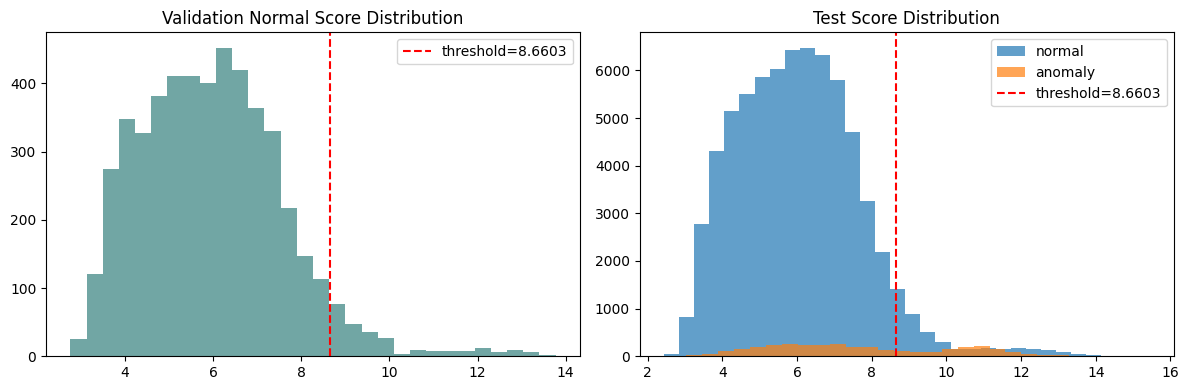

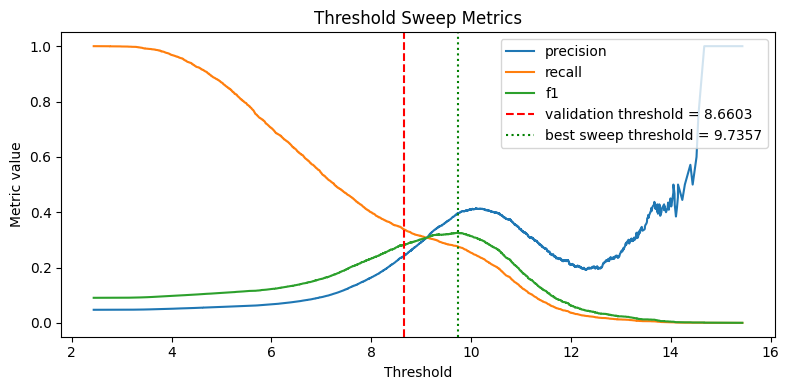

Saved histogram plot to: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x64\wideresnet50A_embedding_baseline\evaluation\plots\score_histograms.png
Saved threshold-sweep plot to: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x64\wideresnet50A_embedding_baseline\evaluation\plots\threshold_sweep_metrics.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(val_scores_df["score"], bins=30, alpha=0.8, color="#4d908e")
axes[0].axvline(threshold, color="red", linestyle="--", label=f"threshold={threshold:.4f}")
axes[0].set_title("Validation Normal Score Distribution")
axes[0].legend()

axes[1].hist(test_scores_df[test_scores_df["is_anomaly"] == 0]["score"], bins=30, alpha=0.7, label="normal")
axes[1].hist(test_scores_df[test_scores_df["is_anomaly"] == 1]["score"], bins=30, alpha=0.7, label="anomaly")
axes[1].axvline(threshold, color="red", linestyle="--", label=f"threshold={threshold:.4f}")
axes[1].set_title("Test Score Distribution")
axes[1].legend()

plt.tight_layout()
hist_path = plots_dir / "score_histograms.png"
plt.savefig(hist_path, dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(threshold_sweep_df["threshold"], threshold_sweep_df["precision"], label="precision")
plt.plot(threshold_sweep_df["threshold"], threshold_sweep_df["recall"], label="recall")
plt.plot(threshold_sweep_df["threshold"], threshold_sweep_df["f1"], label="f1")
plt.axvline(threshold, color="red", linestyle="--", label=f"validation threshold = {threshold:.4f}")
plt.axvline(best_sweep["threshold"], color="green", linestyle=":", label=f"best sweep threshold = {best_sweep['threshold']:.4f}")
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Threshold Sweep Metrics")
plt.legend()
plt.tight_layout()
sweep_path = plots_dir / "threshold_sweep_metrics.png"
plt.savefig(sweep_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved histogram plot to:", hist_path)
print("Saved threshold-sweep plot to:", sweep_path)


c:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


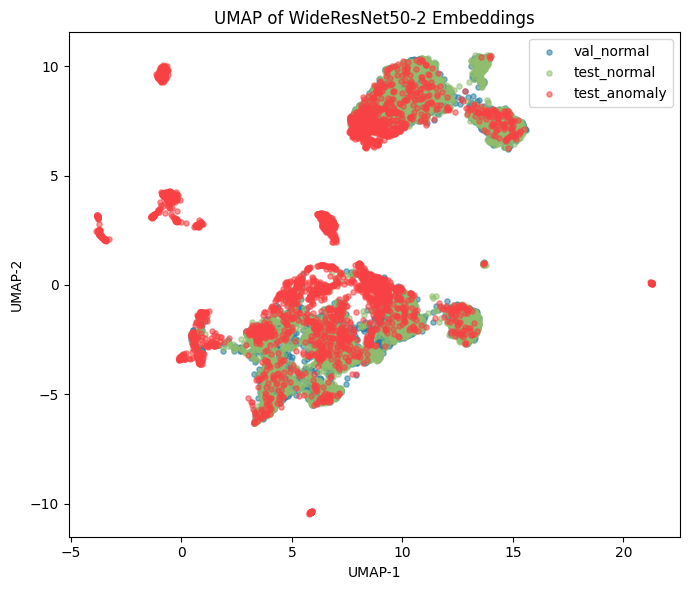

Saved UMAP plot to: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x64\wideresnet50A_embedding_baseline\evaluation\plots\embedding_umap.png


,umap1,umap2,group
0,6.631836,-4.958827,val_normal
1,9.344603,8.865740,val_normal
2,4.894755,-1.214485,val_normal
3,6.419776,-3.688274,val_normal
4,13.672076,9.336023,val_normal


In [11]:
umap_bundle = export_reference_umap_bundle(
    output_dir=eval_dir,
    umap_module=umap,
    train_normal_embeddings=train_embeddings,
    val_embeddings=val_embeddings,
    val_labels=val_labels,
    test_embeddings=test_embeddings,
    test_labels=test_labels,
    val_model_scores=val_scores.astype(np.float32),
    test_model_scores=test_scores.astype(np.float32),
    threshold_quantile=0.95,
    random_state=int(config["run"]["seed"]),
    pca_components=50,
    n_neighbors=15,
    min_dist=0.1,
    knn_k=15,
    metric="euclidean",
    max_train_reference=UMAP_MAX_TRAIN_REFERENCE,
    max_val_normal=UMAP_MAX_POINTS_PER_GROUP,
    max_test_normal=UMAP_MAX_POINTS_PER_GROUP,
    max_test_anomaly=UMAP_MAX_POINTS_PER_GROUP,
    title_prefix="Reference-Fit WideResNet50-2 Embeddings",
    points_filename="embedding_umap_points.csv",
    split_plot_filename="plots/umap_by_split.png",
    score_plot_filename="plots/umap_by_score.png",
    summary_filename="umap_summary.json",
    sweep_filename="umap_knn_threshold_sweep.csv",
)
umap_df = umap_bundle["points_df"]
print("Saved UMAP split plot to:", eval_dir / "plots" / "umap_by_split.png")
print("Saved UMAP score plot to:", eval_dir / "plots" / "umap_by_score.png")
print("Saved UMAP summary to:", eval_dir / "umap_summary.json")
display(umap_df.head())


## Failure Analysis

This section attaches the WideResNet50-2 distance scores to the test metadata and highlights the main error patterns under the validation-derived threshold.


In [11]:
analysis_df = test_dataset.metadata.reset_index(drop=True).copy()
analysis_df["score"] = test_scores_df.reset_index(drop=True)["score"]
analysis_df["predicted_anomaly"] = (analysis_df["score"] > threshold).astype(int)

analysis_df["error_type"] = "tn"
analysis_df.loc[(analysis_df["is_anomaly"] == 0) & (analysis_df["predicted_anomaly"] == 1), "error_type"] = "fp"
analysis_df.loc[(analysis_df["is_anomaly"] == 1) & (analysis_df["predicted_anomaly"] == 0), "error_type"] = "fn"
analysis_df.loc[(analysis_df["is_anomaly"] == 1) & (analysis_df["predicted_anomaly"] == 1), "error_type"] = "tp"

error_summary_df = (
    analysis_df.groupby("error_type")
    .agg(count=("error_type", "size"), mean_score=("score", "mean"))
    .reindex(["tp", "fn", "fp", "tn"])
)

defect_recall_df = (
    analysis_df[analysis_df["is_anomaly"] == 1]
    .groupby("defect_type")
    .agg(count=("defect_type", "size"), detected=("predicted_anomaly", "sum"), mean_score=("score", "mean"))
    .sort_values(["detected", "count"], ascending=[False, False])
)
defect_recall_df["recall"] = defect_recall_df["detected"] / defect_recall_df["count"]

display(error_summary_df)
display(defect_recall_df)
analysis_df.head()


,count,mean_score
error_type,,
tp,67,10.634568
fn,183,6.274493
fp,235,10.077269
tn,4765,5.815561


,count,detected,mean_score,recall
defect_type,,,,
Edge-Ring,84,39,8.337156,0.464286
Edge-Loc,53,7,6.356404,0.132075
Center,50,7,7.073292,0.140000
Loc,34,6,7.076749,0.176471
Scratch,15,3,7.406446,0.200000
Random,5,3,9.772096,0.600000
Donut,7,2,7.723980,0.285714
Near-full,2,0,7.619324,0.000000


,array_path,label,defect_type,is_anomaly,split,source_split,original_height,original_width,score,predicted_anomaly,error_type
0,data/processed/x64/wm811k/arrays/wafer_0045000...,none,none,0,test,Training,33,37,5.613274,0,tn
1,data/processed/x64/wm811k/arrays/wafer_0045001...,none,none,0,test,Training,27,25,6.982519,0,tn
2,data/processed/x64/wm811k/arrays/wafer_0045002...,none,none,0,test,Test,41,42,6.808879,0,tn
3,data/processed/x64/wm811k/arrays/wafer_0045003...,none,none,0,test,Training,27,27,4.760010,0,tn
4,data/processed/x64/wm811k/arrays/wafer_0045004...,none,none,0,test,Test,30,34,3.674251,0,tn


In [8]:
output_dir = REPO_ROOT / config["run"]["output_dir"]
eval_dir = output_dir / "evaluation"
plots_dir = eval_dir / "plots"
output_dir.mkdir(parents=True, exist_ok=True)
eval_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

print("Output directory:", output_dir)


Output directory: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x64\wideresnet50A_embedding_baseline


In [ ]:
from pathlib import Path
import pandas as pd

umap_csv = eval_dir / "embedding_umap_points.csv"
dumap_summary_path = eval_dir / "umap_summary.json"

df = pd.read_csv(umap_csv)
display(df.head())
print(df["split_label"].value_counts(dropna=False))
print("UMAP CSV:", umap_csv)
print("UMAP summary:", umap_summary_path)


In [ ]:
import json

with (eval_dir / "umap_summary.json").open("r", encoding="utf-8") as f:
    umap_summary = json.load(f)

print("UMAP plot counts:", umap_summary.get("plot_counts", {}))
print("UMAP full counts:", umap_summary.get("counts", {}))
print("UMAP params:", umap_summary.get("umap_params", {}))
print("UMAP-KNN metrics:", umap_summary.get("umap_knn_metrics", {}))


In [ ]:
# Optional note:
# This baseline notebook now uses the same standardized reference-fit UMAP export
# workflow as the PatchCore notebooks. For fair report comparison, use the saved
# split plot, score plot, and umap_summary.json rather than the older manual
# overlap-analysis path.


In [ ]:
# Intentionally left as a no-op placeholder to preserve notebook numbering
# after standardizing the UMAP workflow.


In [ ]:
# Intentionally left as a no-op placeholder to preserve notebook numbering
# after standardizing the UMAP workflow.
